# Imports

In [91]:
import torch 
from torch import nn
from torch import optim
from torch.utils.data import DataLoader
from torch.utils.data import Dataset


import torch.nn.functional as F
import random

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np


import copy
from itertools import zip_longest

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, ndcg_score, average_precision_score
from sklearn.metrics import mean_squared_error

from collections import defaultdict


# Load Data

In [83]:
ratings = pd.read_csv('/Users/gracefujinaga/MSDS_490/Data/movie_lens/ml-1m/ratings.dat',sep='::', names=['user_id', 'movie_id', 'rating', 'timestamp'])
ratings.head()

/var/folders/zv/4f9cw9vs6tjbvz5bh2k07w_40000gn/T/ipykernel_82627/3114941495.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  ratings = pd.read_csv('/Users/gracefujinaga/MSDS_490/Data/movie_lens/ml-1m/ratings.dat',sep='::', names=['user_id', 'movie_id', 'rating', 'timestamp'])


,user_id,movie_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [5]:
movies = pd.read_csv('/Users/gracefujinaga/MSDS_490/Data/movie_lens/ml-1m/movies.dat',sep='::', names=['movie_id', 'title', 'genres'],  encoding='latin-1' )
movies.head()

/var/folders/zv/4f9cw9vs6tjbvz5bh2k07w_40000gn/T/ipykernel_82627/4004271770.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  movies = pd.read_csv('/Users/gracefujinaga/MSDS_490/Data/movie_lens/ml-1m/movies.dat',sep='::', names=['movie_id', 'title', 'genres'],  encoding='latin-1' )


,movie_id,title,genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


# GR Model

Note: I have an M1 chip so I VERY simply "replicated" the facebook research here

## Prepare Data

In [93]:
class SequenceDataset(Dataset):
    def __init__(self, samples):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        input_seq, target = self.samples[idx]
        return torch.tensor(input_seq, dtype=torch.long), torch.tensor(target, dtype=torch.long)


In [85]:
# Create sequences for each user
ratings = ratings.sort_values(by=["user_id", "timestamp"])

# Group by user: convert each user’s interaction into a sequence
user_sequences = ratings.groupby("user_id")["movie_id"].apply(list).tolist()

# Show an example
print("Sample user sequence:", user_sequences[0][:10])


Sample user sequence: [3186, 1270, 1721, 1022, 2340, 1836, 3408, 2804, 1207, 1193]


In [88]:
def generate_samples(sequences, max_len=5):
    samples = []
    for seq in sequences:
        for i in range(2, len(seq)):
            input_seq = seq[:i]
            if len(input_seq) > max_len:
                input_seq = input_seq[-max_len:]
            target = seq[i]
            padded = [0] * (max_len - len(input_seq)) + input_seq
            samples.append((padded, target))
    return samples

samples = generate_samples(user_sequences)


Input sequence: [0, 0, 0, 3186, 1270]
Target item: 1721


In [94]:
train_samples, val_samples = train_test_split(samples, test_size=0.2, random_state=42)

In [95]:
batch_size = 64

train_dataset = SequenceDataset(train_samples)
val_dataset = SequenceDataset(val_samples)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, drop_last=False)

dataloaders = {'train': train_loader, 'val': val_loader}
dataset_sizes = {'train': len(train_dataset), 'val': len(val_dataset)}

In [96]:
# number of movies and users
n_movies = len(ratings['movie_id'].unique())
print(f"number of movies: {n_movies}")

n_users = len(ratings['user_id'].unique())
print(f"number of users: {n_users}")


number of movies: 3706
number of users: 6040


## Model

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class SimpleGenerativeRec(nn.Module):
    def __init__(self, n_movies, embed_dim=32, num_heads=2):
        super().__init__()
        self.embedding = nn.Embedding(n_movies + 1, embed_dim) 
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            batch_first=True
        )
        self.decoder = nn.TransformerDecoder(decoder_layer, num_layers=1)
        self.output = nn.Linear(embed_dim, n_movies + 1)

    def forward(self, x):
        emb = self.embedding(x)
        tgt_mask = torch.triu(torch.ones(x.size(1), x.size(1)) * float('-inf'), diagonal=1).to(device)
        memory = torch.zeros_like(emb).to(device)
        decoded = self.decoder(emb, memory, tgt_mask=tgt_mask)
        return self.output(decoded)

In [97]:
# define model
model = SimpleGenerativeRec(n_movies)


#### param#####
lr = 1e-3
wd = 1e-5
n_epochs = 200
patience = 10
#### param#####

# criteria is cross entropy loss because it is classification
criterion = nn.CrossEntropyLoss()  
optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)

no_improvements = 0
best_loss = float('inf')
best_weights = None
history = []

for epoch in range(n_epochs):
    stats = {'epoch': epoch + 1, 'total': n_epochs}

    for phase in ('train', 'val'):
        training = (phase == 'train')
        if training:
            model.train()
        else:
            model.eval()

        running_loss = 0.0

        for input_seqs, target_items in dataloaders[phase]:
            input_seqs = input_seqs.to(device)
            target_items = target_items.to(device)

            optimizer.zero_grad()
            with torch.set_grad_enabled(training):
                logits = model(input_seqs)
                preds = logits[:, -1, :]  # predict next item from last token output
                loss = criterion(preds, target_items)
                if training:
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * input_seqs.size(0)  # sum loss for batch

        epoch_loss = running_loss / dataset_sizes[phase]
        stats[phase] = epoch_loss

        if phase == 'val':
            if epoch_loss < best_loss:
                best_loss = epoch_loss
                best_weights = copy.deepcopy(model.state_dict())
                no_improvements = 0
            else:
                no_improvements += 1

    history.append(stats)
    print('[{epoch:03d}/{total:03d}] train: {train:.4f}, val: {val:.4f}'.format(**stats))

    if no_improvements >= patience:
        print(f'Early stopping on epoch {epoch+1}')
        break

# Load best weights
model.load_state_dict(best_weights)



[001/200] train: 7.3024, val: 6.0558
[002/200] train: 5.3583, val: 4.8918
[003/200] train: 4.7535, val: 4.6916
[004/200] train: 4.6291, val: 4.6631
[005/200] train: 4.5639, val: 4.6822
[006/200] train: 4.5180, val: 4.7068
[007/200] train: 4.4611, val: 4.7199
[008/200] train: 4.4080, val: 4.7381
[009/200] train: 4.3524, val: 4.7657
[010/200] train: 4.2953, val: 4.8113
[011/200] train: 4.2221, val: 4.8576
[012/200] train: 4.1557, val: 4.9014
[013/200] train: 4.0817, val: 4.9362
[014/200] train: 4.0112, val: 4.9554
Early stopping on epoch 14


<All keys matched successfully>

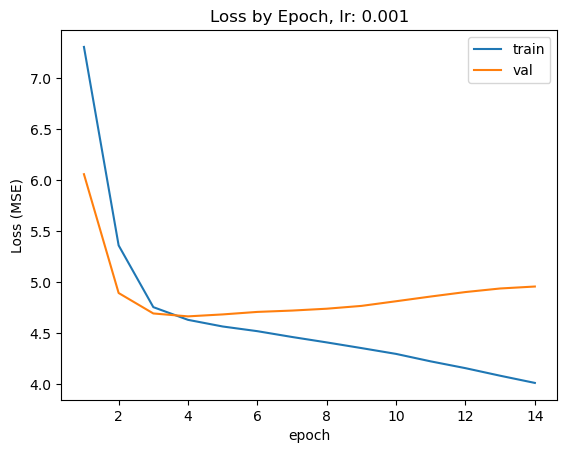

In [98]:
ax = pd.DataFrame(history).drop(columns='total').plot(x='epoch')
ax.set_title(f'Loss by Epoch, lr: {lr}')
ax.set_ylabel('Loss (MSE)')  
plt.show()

In [109]:
# convert the val_samples to tensor
sequences = [seq for seq, target in val_samples]
targets = [target for seq, target in val_samples]
X_test_tensor = torch.LongTensor(sequences).to(device)

model.load_state_dict(best_weights)
model.eval()

with torch.no_grad():
    preds = model(X_test_tensor)  
    last_logits = preds[:, -1, :]  
    y_pred = torch.argmax(last_logits, dim=1).cpu().numpy()


## Evaluate

In [123]:
def precision_at_k(topk_preds, targets, k):
    hits = 0
    for i in range(len(targets)):
        if targets[i] in topk_preds[i]:
            hits += 1
    return hits / len(targets)

def ndcg_at_k(topk_preds, targets, k, n_items, last_logits):
    # Prepare binary relevance matrix
    y_true = np.zeros((len(targets), n_items))
    for i, t in enumerate(targets):
        y_true[i, t] = 1

    # Convert model raw output logits to numpy
    y_score = last_logits.cpu().numpy()  # shape: (batch_size, n_items)

    # Compute NDCG@k using sklearn (which expects full relevance and scores vectors)
    ndcg = ndcg_score(y_true, y_score, k=k)

    return ndcg

def recall_at_k(topk_preds, targets, k):
    hits = 0
    for preds, true_item in zip(topk_preds, targets):
        if true_item in preds[:k]:
            hits += 1
    return hits / len(targets)


In [124]:
k = 10
with torch.no_grad():
    preds = model(X_test_tensor)  # (batch_size, seq_len, n_movies + 1)
    last_logits = preds[:, -1, :]  # (batch_size, n_movies + 1)
    topk_preds = torch.topk(last_logits, k=k, dim=1).indices.cpu().numpy()

    n_items = last_logits.shape[-1]  # total number of items

    ndcg = ndcg_at_k(topk_preds, targets, k, n_items, last_logits)
    print(f'NDCG@{k}: {ndcg:.4f}')

    precision = precision_at_k(topk_preds, targets, k)
    print(f'precision@{k}: {precision:.4f}')

    recall = recall_at_k(topk_preds, targets, k)
    print(f'recall@{k}: {recall:.4f}')


k = 100
with torch.no_grad():
    preds = model(X_test_tensor)  # (batch_size, seq_len, n_movies + 1)
    last_logits = preds[:, -1, :]  # (batch_size, n_movies + 1)
    topk_preds = torch.topk(last_logits, k=k, dim=1).indices.cpu().numpy()

    n_items = last_logits.shape[-1]  # total number of items

    ndcg = ndcg_at_k(topk_preds, targets, k, n_items, last_logits)
    print(f'NDCG@{k}: {ndcg:.4f}')

    precision = precision_at_k(topk_preds, targets, k)
    print(f'precision@{k}: {precision:.4f}')

    recall = recall_at_k(topk_preds, targets, k)
    print(f'recall@{k}: {recall:.4f}')


NDCG@10: 0.0428
precision@10: 0.0925
recall@10: 0.0925
NDCG@100: 0.2101
precision@100: 1.0000
recall@100: 1.0000


# DLRM Model: NCF

## Set up Dataset and Test/Train Split

In [66]:
# set up user to index mapping
unique_users = ratings.user_id.unique()
user_to_index = {old: new for new, old in enumerate(unique_users)}
new_users = ratings.user_id.map(user_to_index)

# set up movie to index mapping
unique_movies = ratings.movie_id.unique()
movie_to_index = {old: new for new, old in enumerate(unique_movies)}
new_movies = ratings.movie_id.map(movie_to_index)

# get num users
n_users = len(unique_users)
n_movies = len(unique_movies)
    
X = pd.DataFrame({'user_id': new_users, 'movie_id': new_movies})
y = ratings['rating'].astype(np.float32)

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=1)

In [67]:
print(f'{n_users} users, {n_movies} movies')
print(f'Dataset shape: {X.shape}')
print(f'Target shape: {y.shape}')

6040 users, 3706 movies
Dataset shape: (1000209, 2)
Target shape: (1000209,)


In [68]:
class RatingsDataset(Dataset):
    def __init__(self, X, y):
        self.users = X['user_id'].values
        self.items = X['movie_id'].values
        self.ratings = y.values

    def __len__(self):
        return len(self.ratings)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.users[idx], dtype=torch.long),
            torch.tensor(self.items[idx], dtype=torch.long),
            torch.tensor(self.ratings[idx], dtype=torch.float)
        )

# Setup data
bs = 200
train_loader = DataLoader(RatingsDataset(X_train[['user_id', 'movie_id']], y_train), batch_size=bs, shuffle=True)
valid_loader = DataLoader(RatingsDataset(X_valid[['user_id', 'movie_id']], y_valid), batch_size=bs, shuffle=False)

dataloaders = {'train': train_loader, 'val': valid_loader}
dataset_sizes = {'train': len(X_train), 'val': len(X_valid)}

## Model and Training

In [69]:
# NCF model
class NCF(nn.Module):
    def __init__(self, num_users, num_items, embedding_dim=64):
        super(NCF, self).__init__()
        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.item_embedding = nn.Embedding(num_items, embedding_dim)

        self.mlp = nn.Sequential(
            nn.Linear(embedding_dim * 2, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, user_indices, item_indices):
        user_embed = self.user_embedding(user_indices)
        item_embed = self.item_embedding(item_indices)
        x = torch.cat([user_embed, item_embed], dim=-1)
        out = self.mlp(x)
        return out.squeeze()  


In [ ]:
# set up and define model
num_users = max(X_train['user_id']) + 1
num_items = max(X_train['movie_id']) + 1
ncf = NCF(num_users, num_items, embedding_dim=64)

####### training param ########
lr = 1e-3
wd = 1e-5
n_epochs = 200
patience = 10

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ncf.to(device)

criterion = nn.MSELoss(reduction='sum')
optimizer = optim.Adam(ncf.parameters(), lr=lr, weight_decay=wd)

# Training loop
no_improvements = 0
best_loss = float('inf')
best_weights = None
history = []

for epoch in range(n_epochs):
    stats = {'epoch': epoch + 1, 'total': n_epochs}

    for phase in ('train', 'val'):
        training = (phase == 'train')
        ncf.train() if training else ncf.eval()

        running_loss = 0.0

        for user_ids, item_ids, ratings in dataloaders[phase]:
            user_ids = user_ids.to(device)
            item_ids = item_ids.to(device)
            ratings = ratings.to(device)

            optimizer.zero_grad()
            with torch.set_grad_enabled(training):
                preds = ncf(user_ids, item_ids)
                loss = criterion(preds, ratings)
                if training:
                    loss.backward()
                    optimizer.step()
            running_loss += loss.item()

        epoch_loss = running_loss / dataset_sizes[phase]
        stats[phase] = epoch_loss

        if phase == 'val':
            if epoch_loss < best_loss:
                best_loss = epoch_loss
                best_weights = copy.deepcopy(ncf.state_dict())
                no_improvements = 0
            else:
                no_improvements += 1

    history.append(stats)
    print('[{epoch:03d}/{total:03d}] train: {train:.4f}, val: {val:.4f}'.format(**stats))

    if no_improvements >= patience:
        print(f'Early stopping on epoch {epoch+1}')
        break

# Load best weights
ncf.load_state_dict(best_weights)


[001/200] train: 1.0134, val: 0.8815
[002/200] train: 0.8496, val: 0.8554
[003/200] train: 0.8251, val: 0.8451
[004/200] train: 0.8112, val: 0.8529
[005/200] train: 0.8001, val: 0.8391
[006/200] train: 0.7895, val: 0.8366
[007/200] train: 0.7794, val: 0.8367
[008/200] train: 0.7683, val: 0.8347
[009/200] train: 0.7558, val: 0.8375
[010/200] train: 0.7416, val: 0.8407
[011/200] train: 0.7263, val: 0.8489
[012/200] train: 0.7102, val: 0.8476
[013/200] train: 0.6934, val: 0.8601
[014/200] train: 0.6766, val: 0.8679
[015/200] train: 0.6599, val: 0.8792
[016/200] train: 0.6438, val: 0.8793
[017/200] train: 0.6275, val: 0.8923
[018/200] train: 0.6124, val: 0.8995
Early stopping on epoch 18


<All keys matched successfully>

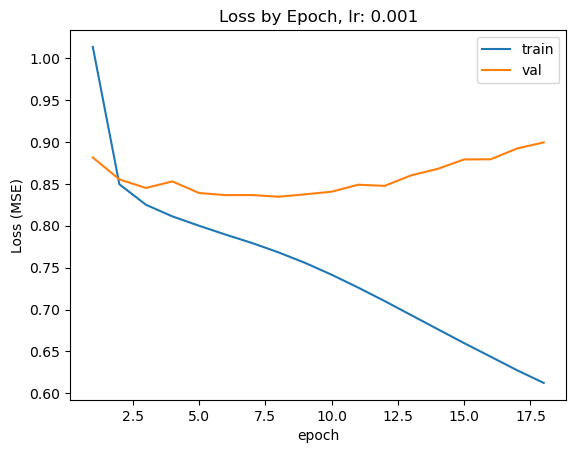

In [71]:
ax = pd.DataFrame(history).drop(columns='total').plot(x='epoch')
ax.set_title(f'Loss by Epoch, lr: {lr}')
ax.set_ylabel('Loss (MSE)')  
plt.show()

In [ ]:
# load weights
ncf.load_state_dict(best_weights)
ncf.eval()

# prepare x_test data
X_test_tensor = torch.LongTensor(np.array(X_valid)).to(device)

with torch.no_grad():
    user_ids = X_test_tensor[:, 0]
    item_ids = X_test_tensor[:, 1]
    preds = ncf(user_ids, item_ids)
    y_pred = preds.cpu().numpy().flatten()

# Compute RMSE
final_loss = np.sqrt(np.mean((np.array(y_pred) - np.array(y_valid)) ** 2))
print(f'Final RMSE: {final_loss:.4f}')


Final RMSE: 0.9136


In [ ]:
results_df = X_valid.copy()
results_df['actual_rating'] = y_valid
results_df.rename(columns={'user_id' : 'userId'}, inplace=True)
results_df['predicted_rating'] = y_pred
results_df

## Evaluate

In [80]:
def precision_at_k_df(df, k=10, threshold=2.5):
    user_est_true = defaultdict(list)

    # Collect predictions per user
    for _, row in df.iterrows():
        uid = row['userId']
        pred = row['predicted_rating']
        actual = row['actual_rating']
        user_est_true[uid].append((pred, actual))

    precisions = dict()
    for uid, user_ratings in user_est_true.items():
        # Sort ratings by predicted score
        user_ratings.sort(key=lambda x: x[0], reverse=True)

        # Top-K items
        top_k = user_ratings[:k]

        # Count how many of top-k are relevant
        n_rec_k = sum(est >= threshold for est, _ in top_k)
        n_rel_and_rec_k = sum((est >= threshold and true_r >= threshold) for est, true_r in top_k)

        precisions[uid] = n_rel_and_rec_k / n_rec_k if n_rec_k != 0 else 0

    return precisions


def recall_at_k_df(df, k=10, threshold=2.5):
    user_est_true = defaultdict(list)

    # Collect predictions per user
    for _, row in df.iterrows():
        uid = row['userId']
        pred = row['predicted_rating']
        actual = row['actual_rating']
        user_est_true[uid].append((pred, actual))

    recalls = dict()
    for uid, user_ratings in user_est_true.items():
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        top_k = user_ratings[:k]

        n_rel = sum(true_r >= threshold for _, true_r in user_ratings)
        n_rel_and_rec_k = sum((est >= threshold and true_r >= threshold) for est, true_r in top_k)

        recalls[uid] = n_rel_and_rec_k / n_rel if n_rel != 0 else 0

    return recalls


def ndcg_at_k(predictions_df, k=10):
    ndcg_results = []

    # Group predictions by user
    grouped = predictions_df.groupby('userId')

    for user_id, group in grouped:
        # sort
        group_sorted = group.sort_values('predicted_rating', ascending=False)

        true_relevance = np.expand_dims(group_sorted['actual_rating'].values, axis=0)
        predicted_scores = np.expand_dims(group_sorted['predicted_rating'].values, axis=0)

        if len(group_sorted) >= k:
            ndcg = ndcg_score(true_relevance, predicted_scores, k=k)
            ndcg_results.append(ndcg)

    mean_ndcg = np.mean(ndcg_results[k])
    return mean_ndcg


def prediction_metrics(predictions_df):
    # precision @k 
    precisions = precision_at_k_df(predictions_df, k=10, threshold=3)
    prec_at_k = sum(prec for prec in precisions.values()) / len(precisions)
    print(f"precision at 10: {prec_at_k}")

    precisions = precision_at_k_df(predictions_df, k=100, threshold=3)
    prec_at_k = sum(prec for prec in precisions.values()) / len(precisions)
    print(f"precision at 100: {prec_at_k}")

    # recall
    recalls = recall_at_k_df(predictions_df, k=10, threshold=3)
    rec_at_k = sum(rec for rec in recalls.values()) / len(recalls)
    print(f"recall at 10: {rec_at_k}")

    recalls = recall_at_k_df(predictions_df, k=100, threshold=3)
    rec_at_k = sum(rec for rec in recalls.values()) / len(recalls)
    print(f"recall at 100: {rec_at_k}")

    # ndcg
    ndcg = ndcg_at_k(predictions_df, k=10)
    print(f"NDCG@10: {ndcg}")

    ndcg = ndcg_at_k(predictions_df, k=100)
    print(f"NDCG@100: {ndcg}")


In [111]:
prediction_metrics(results_df)

precision at 10: 0.9250123556102413
precision at 100: 0.9007493223137176
recall at 10: 0.5557129296813126
recall at 100: 0.8849393563410966
NDCG@10: 0.9051660993065578
NDCG@100: 0.9296560788888077
